<a href="https://colab.research.google.com/github/hakan-karadeniz/Yol-Segmentasyon-Uygulamas-/blob/main/proje1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q gradio torch torchvision opencv-python-headless matplotlib

In [ ]:
!pip install -q opencv-python-headless matplotlib numpy tqdm

In [ ]:
!pip install -q torch torchvision opencv-python-headless matplotlib tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DATA_PATH = '/content/drive/MyDrive/data'
print('Drive bağlandı.')

Mounted at /content/drive
Drive bağlandı.


In [ ]:
import os
import numpy as np

SPLITS = ['train','val']
stats = {}

for split in SPLITS:
  img_dir = os.path.join(DRIVE_DATA_PATH, split, 'image')
  label_dir = os.path.join(DRIVE_DATA_PATH, split, 'label')

  if not os.path.exists(img_dir):
    print(f'[UYARI] {split}/image klasörü bulunamadı.')
    continue

  imgs = set(os.listdir(img_dir))
  labels = set(os.listdir(label_dir))

  ortak = sorted(imgs & labels)
  stats[split] = {'toplam': len(ortak), 'dosyalar': ortak[:5]}
  print(f'{split:5s}: {len(ortak):4d} eşleşen dosya  |  '
          f'{len(imgs)-len(ortak)} görüntü eksik label  |  '
          f'{len(labels)-len(ortak)} label eksik görüntü')

train: 2975 eşleşen dosya  |  0 görüntü eksik label  |  0 label eksik görüntü
val  :  500 eşleşen dosya  |  0 görüntü eksik label  |  0 label eksik görüntü


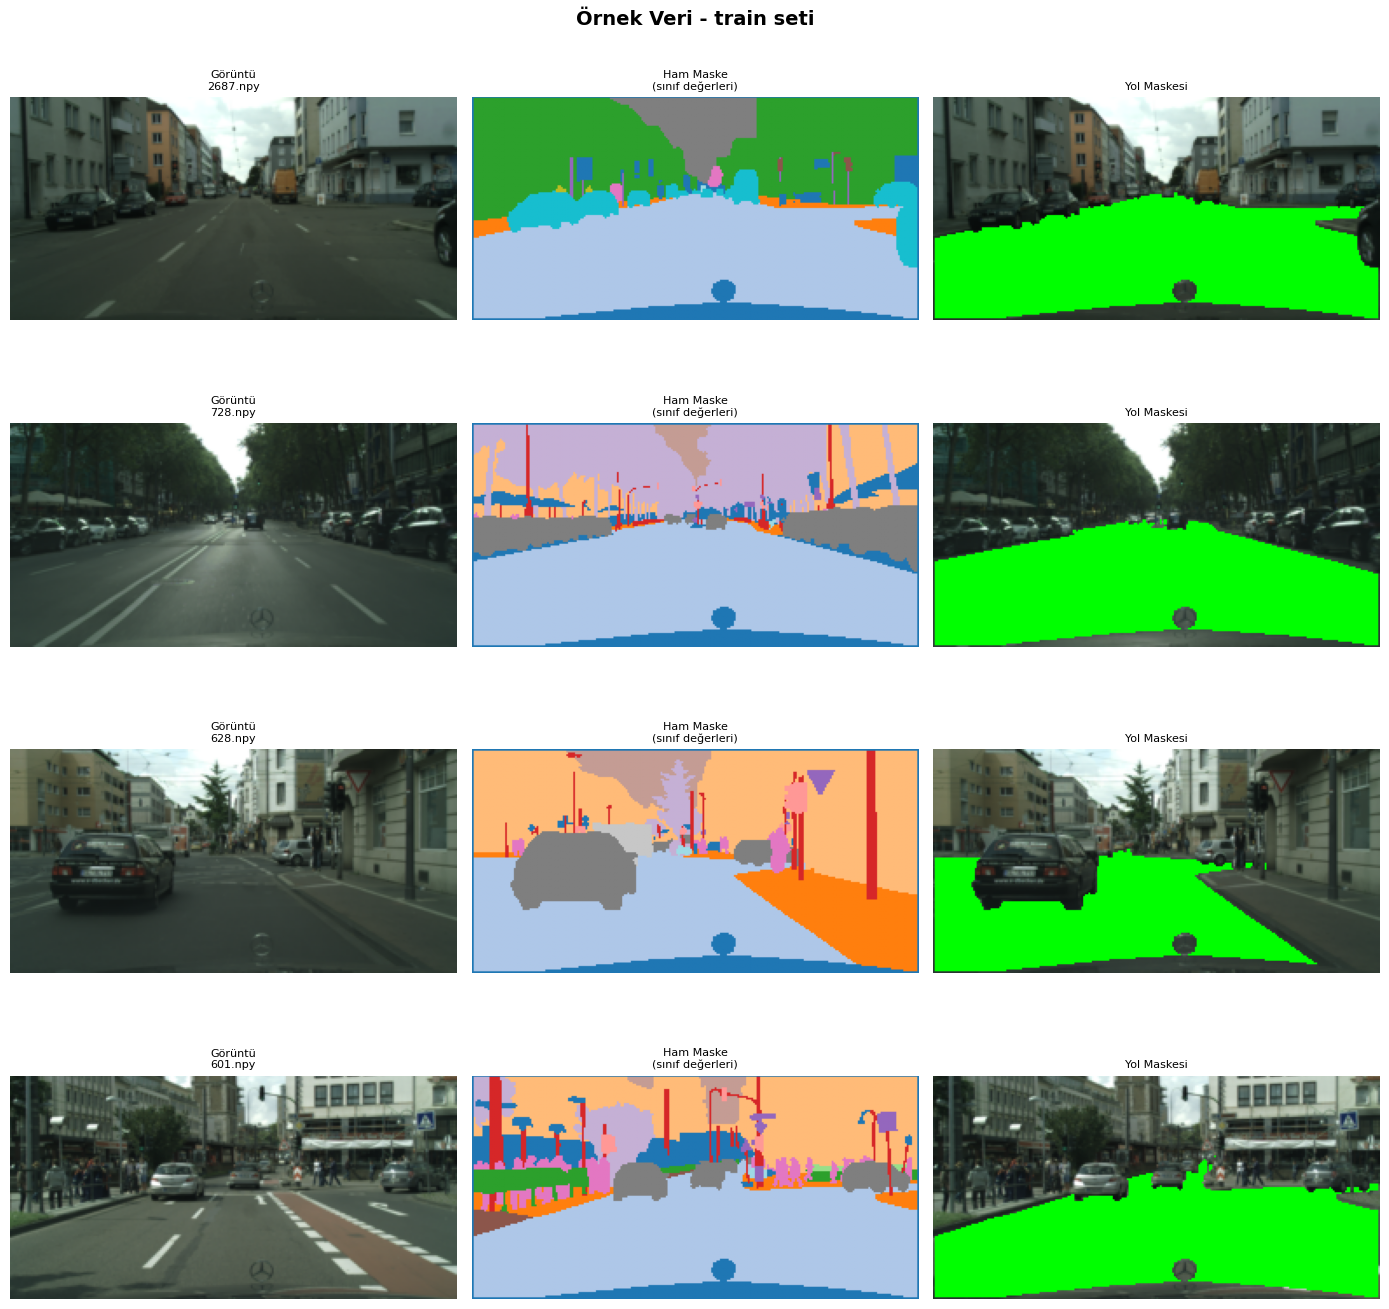

In [ ]:
import matplotlib.pyplot as plt
import numpy as np, os, random

SPLIT = 'train'
N_SHOW = 4

img_dir = os.path.join(DRIVE_DATA_PATH, SPLIT, 'image')
label_dir = os.path.join(DRIVE_DATA_PATH, SPLIT, 'label')
files = sorted(set(os.listdir(img_dir)) & set(os.listdir(label_dir)))
sample = random.sample(files, min(N_SHOW, len(files)))

fig, axes = plt.subplots(N_SHOW, 3, figsize = (14, N_SHOW*3.5))
fig.suptitle(f'Örnek Veri - {SPLIT} seti', fontsize = 14, fontweight = 'bold')

for row, fname in enumerate(sample):
  img = np.load(os.path.join(img_dir, fname))
  mask = np.load(os.path.join(label_dir, fname))
  road_mask = (mask == 0).astype(np.float32)

  # Görüntü
  ax = axes[row, 0] if N_SHOW > 1 else axes[0]
  ax.imshow(np.clip(img, 0, 1))
  ax.set_title(f'Görüntü\n{fname}', fontsize = 8)
  ax.axis('off')

  # Ham Maske
  ax = axes[row, 1] if N_SHOW > 1 else axes[1]
  ax.imshow(mask, cmap = 'tab20')
  ax.set_title(f'Ham Maske\n(sınıf değerleri)', fontsize = 8)
  ax.axis('off')

  # Yol Maskesi
  ax = axes[row, 2] if N_SHOW > 1 else axes[2]
  overlay = np.clip(img.copy(), 0, 1)
  overlay[road_mask == 1] = [0.0, 1.0, 0.0]
  ax.imshow(overlay)
  ax.set_title('Yol Maskesi', fontsize = 8)
  ax.axis('off')

plt.tight_layout()
plt.savefig('ornek_veriler.png', dpi = 120, bbox_inches = 'tight')
plt.show()

In [ ]:
import numpy as np, os
from collections import Counter
import matplotlib.pyplot as plt

SPLIT = 'train'
MAX_DOSYA = 50

label_dir = os.path.join(DRIVE_DATA_PATH, SPLIT, 'label')
img_dir   = os.path.join(DRIVE_DATA_PATH, SPLIT, 'image')
files = sorted(set(os.listdir(img_dir)) & set(os.listdir(label_dir)))[:MAX_DOSYA]

counter = Counter()
for fname in files:
  mask = np.load(os.path.join(label_dir, fname))
  counter.update(mask.flatten().tolist())

siniflar = sorted(counter.keys())
sayilar = [counter[s] for s in siniflar]
toplam = sum(sayilar)
road_oran = counter.get(0,0) / toplam*100

print(f'Toplam piksel: {toplam:,}')
print(f'Yol pikseli (sınıf 0): {counter.get(0,0):,}  ,  %{road_oran:.1f}')
print(f'Benzersiz sınıf sayısı: {len(siniflar)}')

Toplam piksel: 1,638,400
Yol pikseli (sınıf 0): 590,970  ,  %36.1
Benzersiz sınıf sayısı: 19


In [ ]:
import numpy as np, os
from collections import Counter

SPLIT = 'train'
img_dir = os.path.join(DRIVE_DATA_PATH, SPLIT, 'image')
files = sorted(os.listdir(img_dir))[:100]

boyutlar = Counter()
for fname in files:
  arr = np.load(os.path.join(img_dir, fname))
  boyutlar[arr.shape] += 1

print('Görüntü Dağılımı : ')
for boyut, adet in boyutlar.most_common():
  print(f'  {str(boyut):20s}: {adet} dosya')

Görüntü Dağılımı : 
  (128, 256, 3)       : 100 dosya


In [ ]:
CONFIG = {
    "drive_data_path" : '/content/drive/MyDrive/data',
    "base_path" : '/content/data_local',
    "model_dir" : '/content/drive/MyDrive/models',
    "batch_size" : 8,
    "lr" : 1e-4,
    "epochs" : 30,
    "image_size" : (256,128),
    "device" : "cuda",
}

In [ ]:
import os

os.makedirs(CONFIG['base_path'], exist_ok=True)
os.makedirs(CONFIG['model_dir'], exist_ok=True)

print('Kopyalanıyor (bu işlem veri boyutuna göre birkaç dakika sürebilir)...')
!cp -r {CONFIG['drive_data_path']}/* {CONFIG['base_path']}/
print('Kopyalama tamamlandı.')

for split in ['train', 'val']:
    img_dir = os.path.join(CONFIG['base_path'], split, 'image')
    if os.path.exists(img_dir):
        print(f'  {split}: {len(os.listdir(img_dir))} görüntü')

Kopyalanıyor (bu işlem veri boyutuna göre birkaç dakika sürebilir)...
Kopyalama tamamlandı.
  train: 2975 görüntü
  val: 500 görüntü


In [ ]:
SHARED_CODE = '''
import os, random
import torch
import torch.nn as nn
import numpy as np
import cv2
from torch.utils.data import Dataset

# 1
CONFIG = {
    "base_path"  : "/content/data_local",
    "model_dir"  : "/content/drive/MyDrive/models",
    "batch_size" : 8,
    "lr"         : 1e-4,
    "epochs"     : 30,
    "image_size" : (256, 128),
    "device"     : "cuda" if torch.cuda.is_available() else "cpu",
}

# 2
class DiceBCELoss(nn.Module):
    def forward(self, inputs, targets, smooth=1):
        bce = nn.functional.binary_cross_entropy_with_logits(
            inputs, targets, reduction="mean"
        )
        sig = torch.sigmoid(inputs)
        inp_f = sig.view(-1)
        tgt_f = targets.view(-1)
        intersection = (inp_f * tgt_f).sum()
        dice = 1 - (2.0 * intersection + smooth) / \
               (inp_f.sum() + tgt_f.sum() + smooth)
        return bce + dice

# 3
class RoadDataset(Dataset):
    def __init__(self, base_path, split="train"):
        self.split = split
        self.base_dir = os.path.join(base_path, split)
        self.img_dir = os.path.join(self.base_dir, "image")
        self.lbl_dir = os.path.join(self.base_dir, "label")
        imgs = set(os.listdir(self.img_dir))
        labels = set(os.listdir(self.lbl_dir))

        self.files = sorted(imgs & labels)
        print(f"{split}: {len(self.files)} dosya")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img = np.load(os.path.join(self.img_dir, fname)).astype(np.float32)
        mask = np.load(os.path.join(self.lbl_dir, fname))
        road_mask = (mask == 0).astype(np.float32)

        if self.split == "train":

            if random.random() > 0.5:
                img = cv2.flip(img, 1)
                road_mask = cv2.flip(road_mask, 1)
            img = np.clip(img * random.uniform(0.8, 1.2), 0.0, 1.0).astype(np.float32)

            if random.random() > 0.3:
                angle = random.uniform(-8, 8)
                M = cv2.getRotationMatrix2D((128, 64), angle, 1.0)
                img = cv2.warpAffine(img, M, (256, 128))
                road_mask = cv2.warpAffine(road_mask, M, (256, 128), flags=cv2.INTER_NEAREST)

            if random.random() > 0.5:
                img = cv2.GaussianBlur(img, (3, 3), 0)

        W, H = CONFIG["image_size"]
        img = cv2.resize(img, (W, H))
        road_mask = cv2.resize(road_mask, (W, H), interpolation=cv2.INTER_NEAREST)
        road_mask = (road_mask > 0.5).astype(np.float32)

        img_t  = torch.from_numpy(img).permute(2, 0, 1).float()
        mask_t = torch.from_numpy(road_mask).float().unsqueeze(0)
        return img_t, mask_t

# 4
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.1),

            nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1,
                 features=[64, 128, 256, 512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)
        for f in features:
            self.downs.append(DoubleConv(in_channels, f))
            in_channels = f
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, 2, 2))
            self.ups.append(DoubleConv(f * 2, f))
        self.bottleneck  = DoubleConv(features[-1], features[-1] * 2)
        self.final_conv  = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x);
            skips.append(x);
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            x = self.ups[i + 1](torch.cat((skips[i // 2], x), dim=1))
        return self.final_conv(x)
'''
drive_yolu = '/content/drive/MyDrive/models/shared.py'

with open(drive_yolu, 'w') as f:
    f.write(SHARED_CODE)

In [ ]:
import os, sys

sys.path.insert(0, '/content/drive/MyDrive/models')
from shared import CONFIG, RoadDataset, UNet, DiceBCELoss


In [ ]:
from torch.utils.data import DataLoader

train_ds = RoadDataset(CONFIG['base_path'], split = 'train')
val_ds = RoadDataset(CONFIG['base_path'], split = 'val')

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} örnek  |  Val: {len(val_ds)} örnek')
print(f'Train batch sayısı: {len(train_loader)}  |  Val batch sayısı: {len(val_loader)}')

train: 2975 dosya
val: 500 dosya
Train: 2975 örnek  |  Val: 500 örnek
Train batch sayısı: 372  |  Val batch sayısı: 63


In [ ]:
import torch.optim as optim

device = CONFIG['device']
model = UNet().to(device)
loss_fn = DiceBCELoss()

optimizer = optim.Adam(model.parameters(), lr = CONFIG['lr'])

sheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'min', patience = 5, factor = 0.5, min_lr = 1e-6)

BEST_CKPT = '/content/drive/MyDrive/models/road_best.pth'
FINAL_CKPT = '/content/drive/MyDrive/models/road_final.pth'

if os.path.exists(BEST_CKPT):
  model.load_state_dict(torch.load(BEST_CKPT, map_location = device))
  print(f'Mevcut model yüklendi : {BEST_CKPT}')
else:
  print('Sıfırdan eğitim başlayacak.')

Sıfırdan eğitim başlayacak.


In [ ]:
import torch

def compute_iou(preds_bin, targets):
  intersection = (preds_bin * targets).sum((1, 2, 3))
  union = preds_bin.sum((1, 2, 3)) + targets.sum((1, 2, 3)) - intersection
  iou = (intersection + 1e-6) / (union + 1e-6)
  return iou.mean().item()

def compute_f1(preds_bin, targets):
  tp = (preds_bin * targets).sum((1, 2, 3))
  fp = (preds_bin * (1 - targets)).sum((1, 2,3))
  fn = ((1 - preds_bin) * targets).sum((1, 2, 3))
  f1 = (2 * tp + 1e-6) / (2 * tp + fp + fn + 1e-6)
  return f1.mean().item()

In [ ]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizeri, loss_fn, device):
  model.train()
  total_loss, total_iou = 0, 0
  for imgs, masks in tqdm(loader, desc = '  Eğitim', leave = False):
    imgs, masks = imgs.to(device), masks.to(device)
    preds = model(imgs)
    loss = loss_fn(preds,masks)

    optimizer.zero_grad(); loss.backward(); optimizer.step()

    total_loss += loss.item()
    with torch.no_grad():
      total_iou += compute_iou((torch.sigmoid(preds) > 0.5).float(), masks)
  n = len(loader)
  return total_loss / n, total_iou / n

def validate(model, loader, loss_fn, device):
  model.eval()
  total_loss, total_iou, total_f1 = 0, 0, 0
  with torch.no_grad():
    for imgs, masks in tqdm(loader, desc = 'Validasyon', leave = False):
      imgs, masks = imgs.to(device), masks.to(device)
      preds = model(imgs)
      total_loss += loss_fn(preds, masks).item()
      preds_bin   = (torch.sigmoid(preds) > 0.5).float()
      total_iou  += compute_iou(preds_bin, masks)
      total_f1   += compute_f1(preds_bin, masks)
  n = len(loader)
  return total_loss / n, total_iou / n, total_f1 / n

In [ ]:
import os

best_val_loss = float('inf')
train_losses, val_losses = [], []
train_ious, val_ious = [], []

for epoch in range(1, CONFIG['epochs'] + 1):
  t_loss, t_iou = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
  v_loss, v_iou, v_f1 = validate(model,val_loader, loss_fn, device)
  sheduler.step(v_loss)

  train_losses.append(t_loss); val_losses.append(v_loss)
  train_ious.append(t_iou); val_ious.append(v_iou)

  lr_now = optimizer.param_groups[0]['lr']
  print(f'Epoch [{epoch:3d}/{CONFIG["epochs"]}]  '
          f'Train Loss={t_loss:.4f}  IoU={t_iou:.4f}  |  '
          f'Val Loss={v_loss:.4f}  IoU={v_iou:.4f}  F1={v_f1:.4f}  '
          f'lr={lr_now:.6f}')
  if v_loss < best_val_loss:
    best_val_loss = v_loss
    torch.save(model.state_dict(), BEST_CKPT)
    print(f'En iyi model kaydedildi : {BEST_CKPT}')

torch.save(model.state_dict(), FINAL_CKPT)
print(f'Eğitim tamamlandı. Final Model : {FINAL_CKPT}')

NameError: name 'CONFIG' is not defined

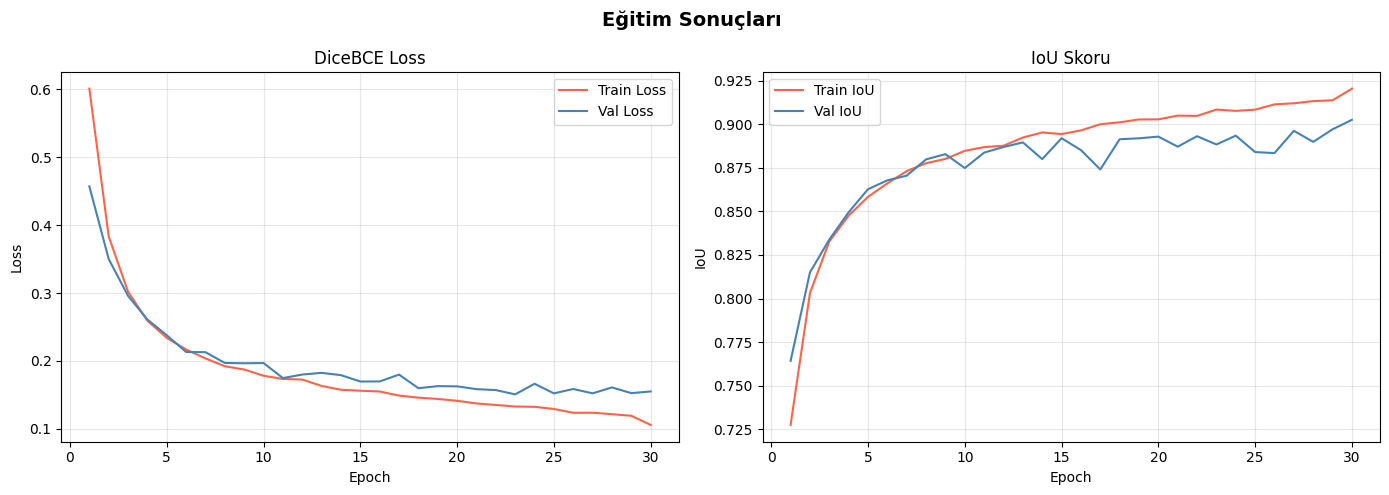

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))
fig.suptitle('Eğitim Sonuçları ', fontsize = 14, fontweight = 'bold')

ax1.plot(epochs_range, train_losses, label='Train Loss', color='tomato')
ax1.plot(epochs_range, val_losses,   label='Val Loss',   color='steelblue')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('DiceBCE Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, train_ious, label='Train IoU', color='tomato')
ax2.plot(epochs_range, val_ious,   label='Val IoU',   color='steelblue')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('IoU')
ax2.set_title('IoU Skoru'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('egitim_grafikleri.png', dpi=120, bbox_inches='tight')
plt.show()

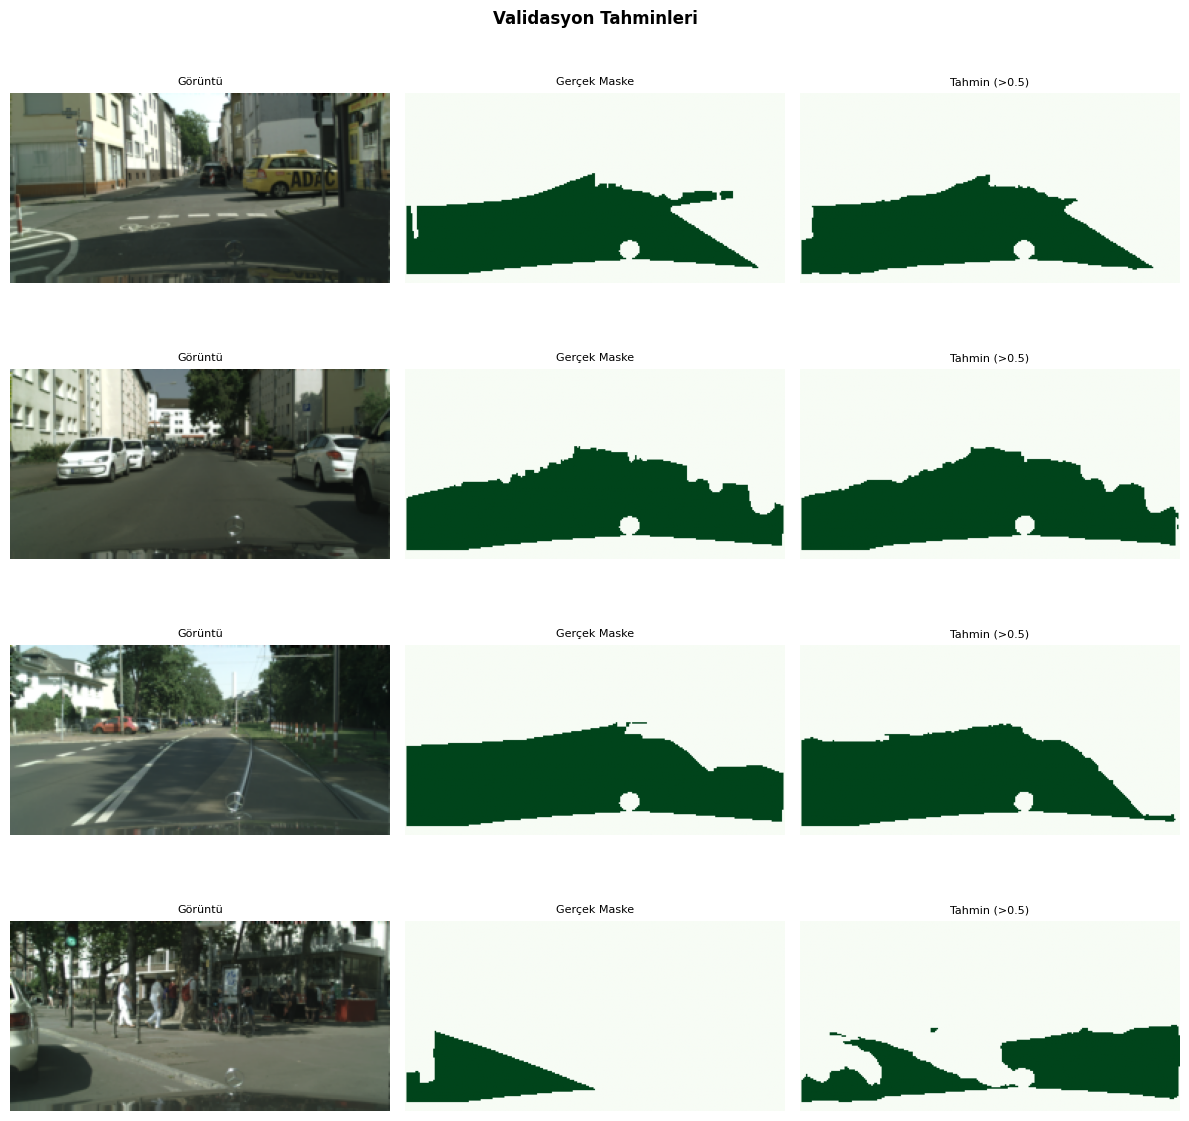

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

model.eval()
imgs, masks = next(iter(val_loader))
with torch.no_grad():
  preds = torch.sigmoid(model(imgs.to(device))).cpu()

N = min(4, imgs.shape[0])
fig, axes = plt.subplots(N, 3, figsize=(12, N * 3))
fig.suptitle('Validasyon Tahminleri', fontsize=12, fontweight='bold')
titles = ['Görüntü', 'Gerçek Maske', 'Tahmin (>0.5)']

for row in range(N):
    ax0, ax1, ax2 = axes[row] if N > 1 else axes
    ax0.imshow(np.clip(imgs[row].permute(1, 2, 0).numpy(), 0, 1))
    ax1.imshow(masks[row].squeeze().numpy(), cmap='Greens')
    ax2.imshow((preds[row].squeeze().numpy() > 0.5), cmap='Greens')
    for ax, t in zip([ax0, ax1, ax2], titles):
        ax.set_title(t, fontsize=8); ax.axis('off')

plt.tight_layout()
plt.savefig('tahmin_ornekleri.png', dpi=120, bbox_inches='tight')
plt.show()